In [5]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('../data/train.csv')
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [7]:
df.shape

(3000888, 6)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [9]:
df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 137.4 MB


In [12]:
# Fecha mínima y máxima
print("Fecha mínima:", df['date'].min())
print("Fecha máxima:", df['date'].max())

# Número de días cubiertos
print("Días cubiertos:", (df['date'].max() - df['date'].min()).days)

Fecha mínima: 2013-01-01 00:00:00
Fecha máxima: 2017-08-15 00:00:00
Días cubiertos: 1687


In [13]:
# Cuántos registros tienen ventas en 0
sales_zero = (df['sales'] == 0).sum()

print(f"Registros con ventas = 0: {sales_zero:,}")
print(f"Porcentaje: {sales_zero / len(df) * 100:.2f}%")

Registros con ventas = 0: 939,130
Porcentaje: 31.30%


In [14]:
df['sales'].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

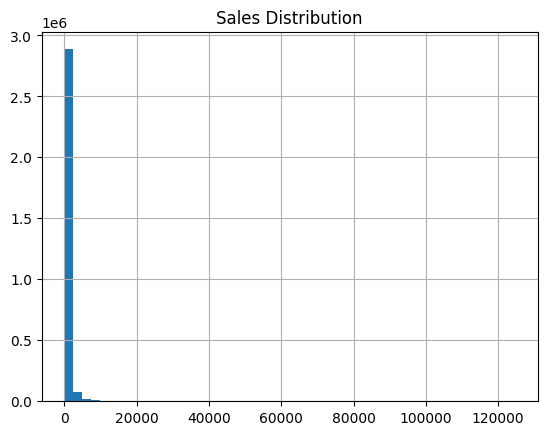

In [15]:
df['sales'].hist(bins=50)
plt.title('Sales Distribution')
plt.show()

In [16]:
# Top categorías con más ventas en cero

(
    df[df['sales'] == 0]
    .groupby('family')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

family
BOOKS                         88167
BABY CARE                     85599
SCHOOL AND OFFICE SUPPLIES    67368
HOME APPLIANCES               66854
LADIESWEAR                    54422
MAGAZINES                     51414
PET SUPPLIES                  49665
HARDWARE                      43524
LAWN AND GARDEN               42544
PLAYERS AND ELECTRONICS       40818
CELEBRATION                   39679
HOME CARE                     37201
HOME AND KITCHEN II           31567
HOME AND KITCHEN I            31505
PRODUCE                       25785
dtype: int64

In [17]:
df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df['store_nbr'].nunique()

54

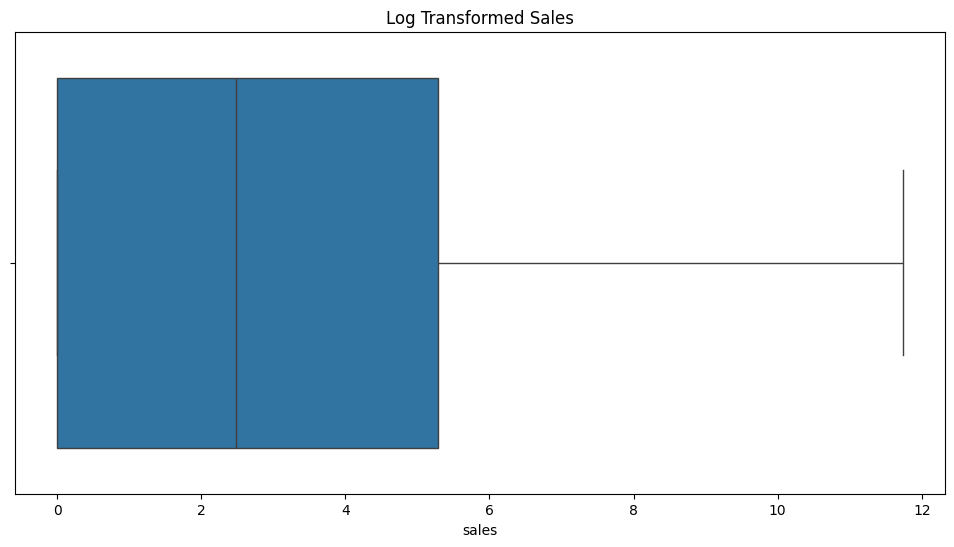

In [20]:
plt.figure(figsize=(12,6))
sns.boxplot(x=np.log1p(df['sales']))
plt.title('Log Transformed Sales')
plt.show()

In [21]:
df['family'].nunique()

33

In [22]:
print(df['date'].min())
print(df['date'].max())

2013-01-01 00:00:00
2017-08-15 00:00:00


In [23]:
df.dtypes

id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object

### Data Quality Assessment

- The dataset contains 3,000,888 observations and 6 variables.
- No missing values were detected.
- No duplicate records were found.
- Sales data covers the period from January 2013 to August 2017.
- The dataset contains 54 stores and 33 product families.
- Approximately 31.3% of observations have zero sales.
- Sales are highly right-skewed, indicating the presence of large sales outliers.

# Exploratory Data Analysis (EDA)

## 1. Sales Trend Analysis

## 2. Monthly Sales Analysis

## 3. Sales by Product Family

## 4. Sales by Store

## 5. Promotion Impact Analysis

## 6. Seasonality Analysis

## 7. Key Insights

## 1. Sales Trend Analysis

In [25]:
daily_sales = (
    df.groupby('date')['sales']
      .sum()
      .reset_index()
)

daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


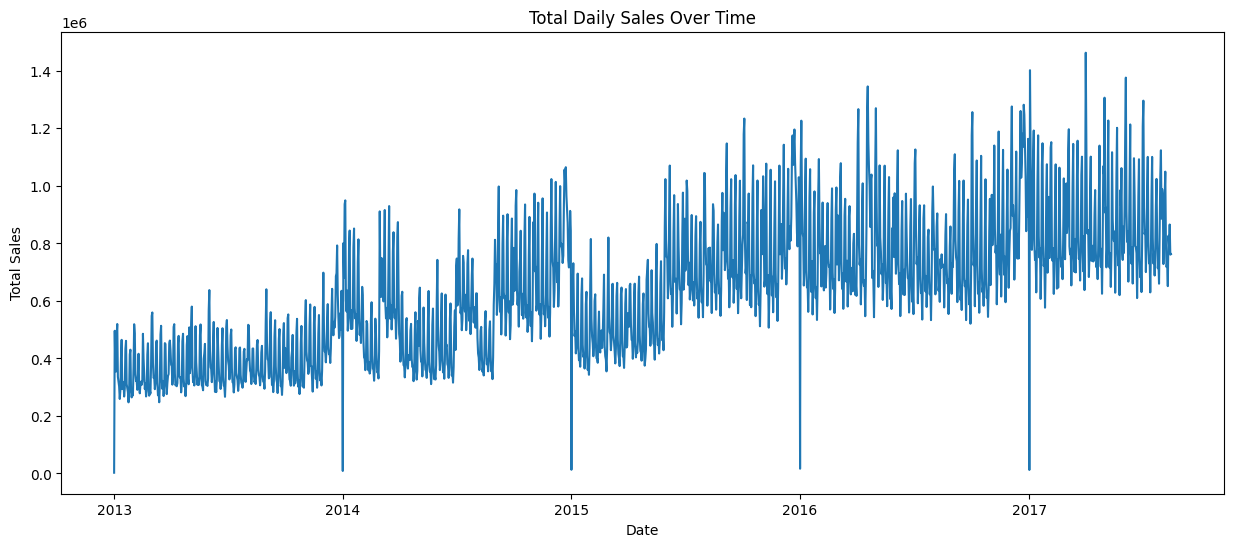

In [26]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales['date'],
    daily_sales['sales']
)

plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.show()

In [27]:
print(f"Average Daily Sales: {daily_sales['sales'].mean():,.2f}")
print(f"Median Daily Sales: {daily_sales['sales'].median():,.2f}")
print(f"Maximum Daily Sales: {daily_sales['sales'].max():,.2f}")
print(f"Minimum Daily Sales: {daily_sales['sales'].min():,.2f}")

Average Daily Sales: 637,556.38
Median Daily Sales: 632,188.86
Maximum Daily Sales: 1,463,083.96
Minimum Daily Sales: 2,511.62


In [28]:
daily_sales['rolling_30d'] = (
    daily_sales['sales']
    .rolling(window=30)
    .mean()
)

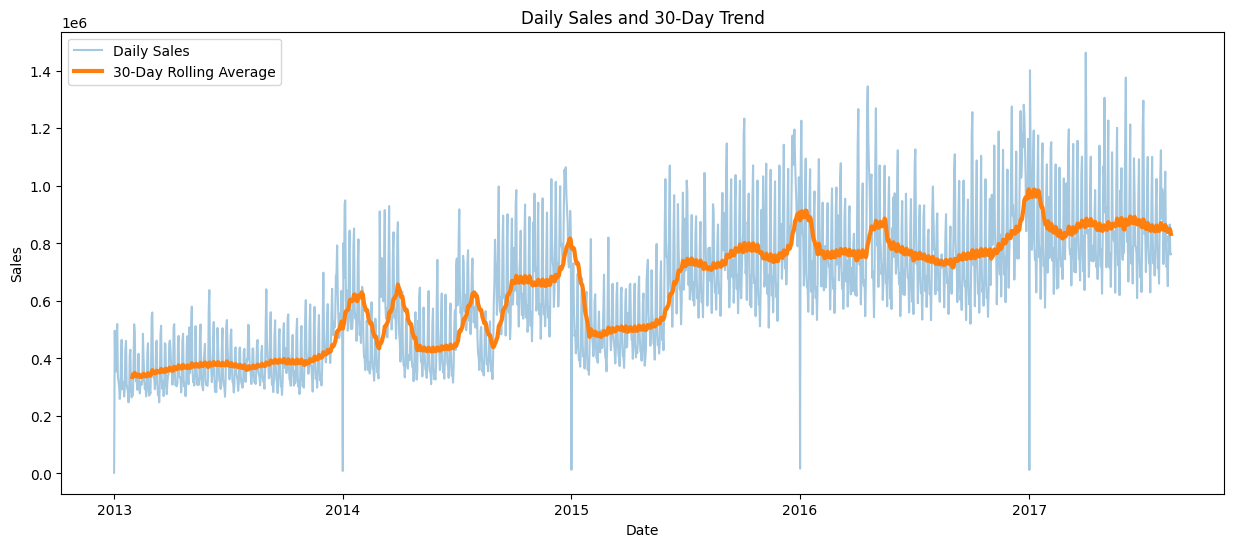

In [29]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales['date'],
    daily_sales['sales'],
    alpha=0.4,
    label='Daily Sales'
)

plt.plot(
    daily_sales['date'],
    daily_sales['rolling_30d'],
    linewidth=3,
    label='30-Day Rolling Average'
)

plt.title('Daily Sales and 30-Day Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.show()

### Initial Observations

- Total sales exhibit a clear upward trend from 2013 to 2017.
- The 30-day rolling average confirms sustained business growth over time.
- Sales volatility increases as total sales grow.
- Recurring peaks suggest the presence of seasonal demand patterns.
- Several isolated dates show unusually low sales values and should be investigated further.
- The dataset appears suitable for time-series forecasting due to the presence of trend and potential seasonality.

## 2. Monthly Sales Analysis

## 3. Sales by Product Family

## 4. Sales by Store

## 5. Promotion Impact Analysis

## 6. Seasonality Analysis

## 7. Key Insights